In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("train.csv")
df.head()

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


In [5]:
df.isnull().sum()

Dates         0
Category      0
Descript      0
DayOfWeek     0
PdDistrict    0
Resolution    0
Address       0
X             0
Y             0
dtype: int64

In [6]:
df.drop_duplicates()

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541
...,...,...,...,...,...,...,...,...,...
878044,2003-01-06 00:15:00,ROBBERY,ROBBERY ON THE STREET WITH A GUN,Monday,TARAVAL,NONE,FARALLONES ST / CAPITOL AV,-122.459033,37.714056
878045,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,INGLESIDE,NONE,600 Block of EDNA ST,-122.447364,37.731948
878046,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,SOUTHERN,NONE,5TH ST / FOLSOM ST,-122.403390,37.780266
878047,2003-01-06 00:01:00,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM OF VEHICLES",Monday,SOUTHERN,NONE,TOWNSEND ST / 2ND ST,-122.390531,37.780607


In [7]:
df["Category"].value_counts()

LARCENY/THEFT                  174900
OTHER OFFENSES                 126182
NON-CRIMINAL                    92304
ASSAULT                         76876
DRUG/NARCOTIC                   53971
VEHICLE THEFT                   53781
VANDALISM                       44725
WARRANTS                        42214
BURGLARY                        36755
SUSPICIOUS OCC                  31414
MISSING PERSON                  25989
ROBBERY                         23000
FRAUD                           16679
FORGERY/COUNTERFEITING          10609
SECONDARY CODES                  9985
WEAPON LAWS                      8555
PROSTITUTION                     7484
TRESPASS                         7326
STOLEN PROPERTY                  4540
SEX OFFENSES FORCIBLE            4388
DISORDERLY CONDUCT               4320
DRUNKENNESS                      4280
RECOVERED VEHICLE                3138
KIDNAPPING                       2341
DRIVING UNDER THE INFLUENCE      2268
RUNAWAY                          1946
LIQUOR LAWS 

SOUTHERN      157182
MISSION       119908
NORTHERN      105296
BAYVIEW        89431
CENTRAL        85460
TENDERLOIN     81809
INGLESIDE      78845
TARAVAL        65596
PARK           49313
RICHMOND       45209
Name: PdDistrict, dtype: int64


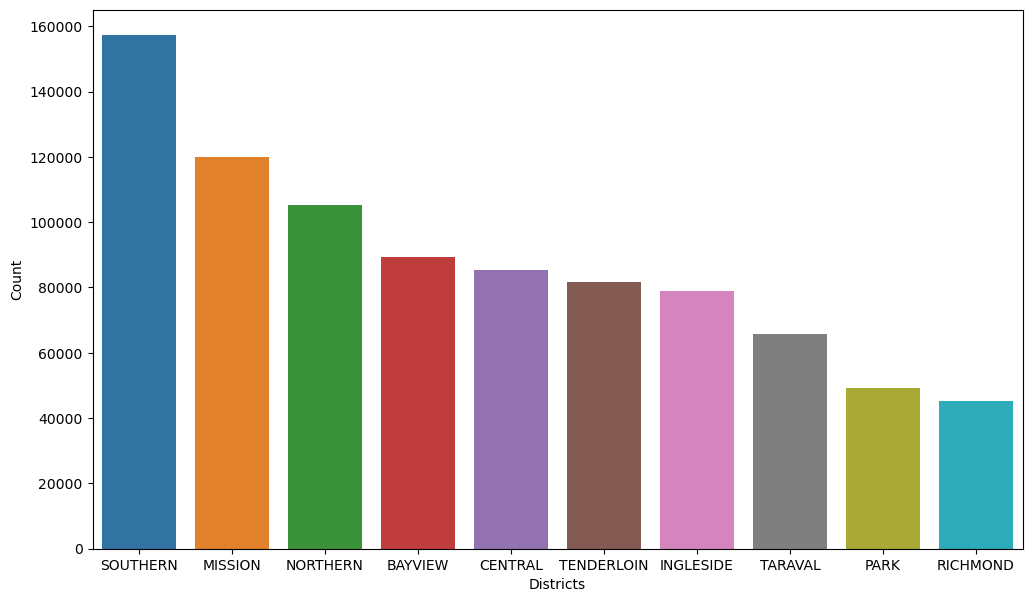

In [8]:
PdDistrict_counts = df["PdDistrict"].value_counts()
print(PdDistrict_counts)

plt.figure(figsize = (12,7))
sns.barplot(x = PdDistrict_counts.index, y = PdDistrict_counts.values)
plt.xlabel("Districts")
plt.ylabel("Count")
plt.show()

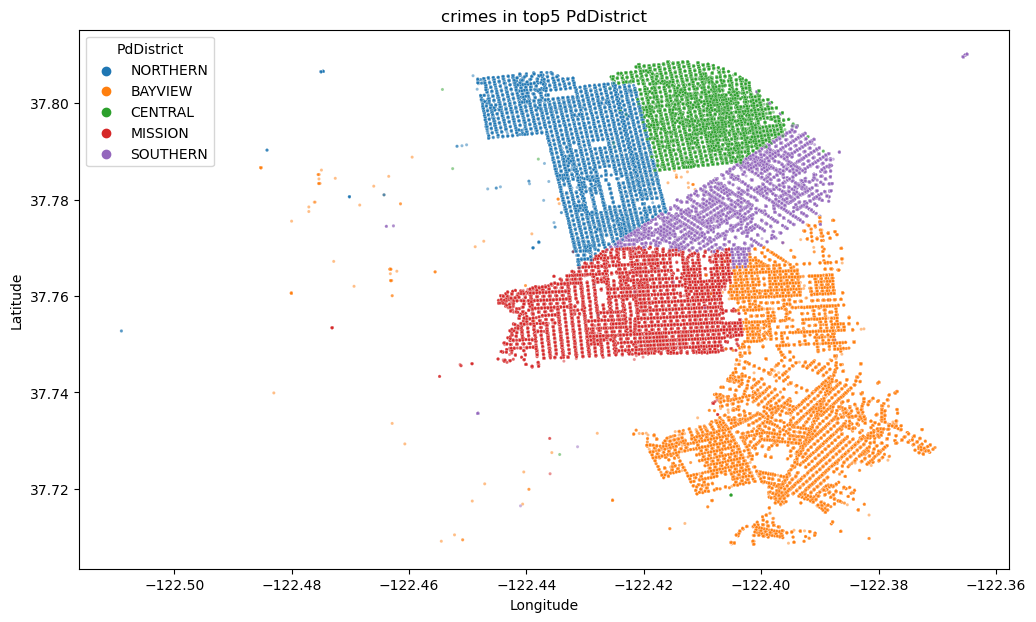

In [9]:
top5_dis = df["PdDistrict"].value_counts().nlargest(5).index.tolist()

plot = df[df["PdDistrict"].isin(top5_dis)]

plot = plot[plot["Y"] < 80]
#plot = plot[plot["X"] < -121]    both decrease skewness

plt.figure(figsize = (12,7))
sns.scatterplot(data = plot, x = "X" , y = "Y" , hue = "PdDistrict", alpha = 0.5, s = 5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("crimes in top5 PdDistrict")

plt.show()

This data is highly imbalanced hence i will not consider it


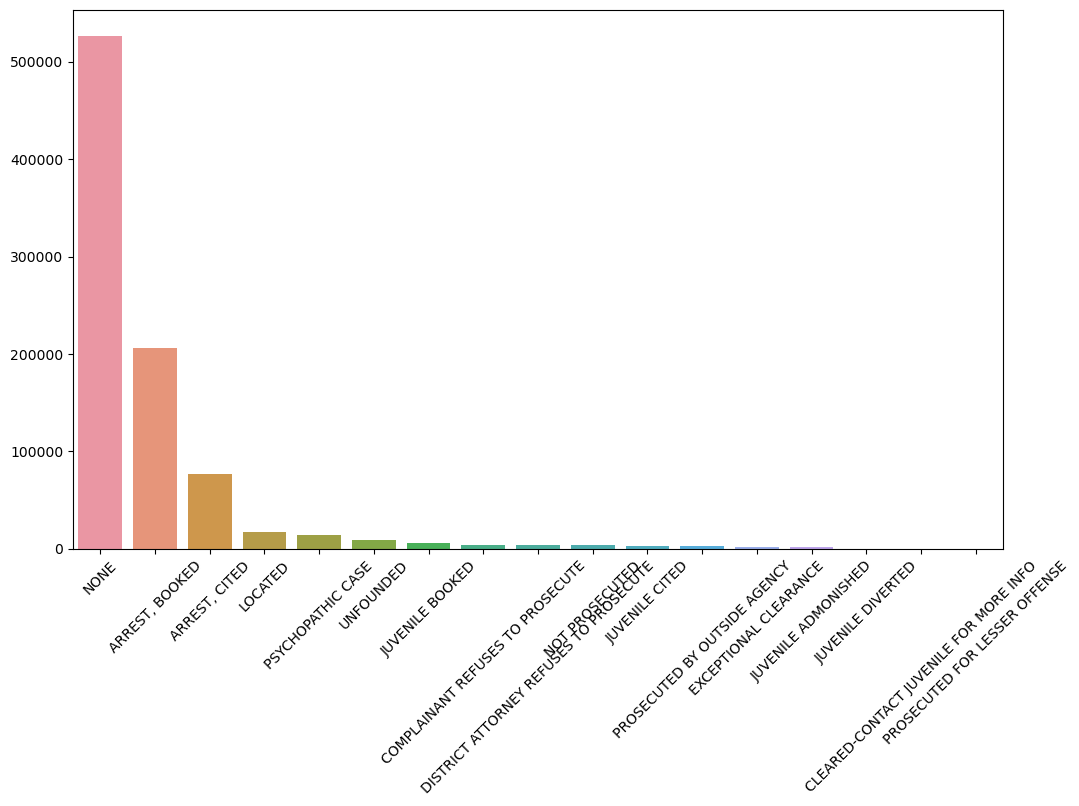

In [10]:
res_count = df["Resolution"].value_counts()


print("This data is highly imbalanced hence i will not consider it")


plt.figure(figsize = (12,7))
sns.barplot(x = res_count.index, y = res_count.values)
plt.xticks(rotation = 45)
plt.show()




In [11]:
df["Descript"].value_counts()

GRAND THEFT FROM LOCKED AUTO                              60022
LOST PROPERTY                                             31729
BATTERY                                                   27441
STOLEN AUTOMOBILE                                         26897
DRIVERS LICENSE, SUSPENDED OR REVOKED                     26839
                                                          ...  
ENCOURAGE MINOR TO USE CONTROLLED SUBSTANCE                   1
BIGAMY, INCEST, AND THE CRIME AGAINST NATURE (GENERAL)        1
DISTURBANCE OF NON-RELIGIOUS, NON-POLITICAL ASSEMBLY          1
CABLE TV CONNECTION OR DECODING DEVICE, UNAUTHORIZED          1
EMBEZZLEMENT, GRAND THEFT PUBLIC/PRIVATE OFFICIAL             1
Name: Descript, Length: 879, dtype: int64

In [14]:
des_counts = df["Descript"].value_counts()

# plt.figure(figsize = (12,7))
# sns.barplot(x = des_counts.index, y = des_counts.values)
# plt.xticks(rotation = 90)
# plt.show()

print("this data is also imbalanced hence i will not consider it")

this data is also imbalanced hence i will not consider it


Friday       133734
Wednesday    129211
Saturday     126810
Thursday     125038
Tuesday      124965
Monday       121584
Sunday       116707
Name: DayOfWeek, dtype: int64


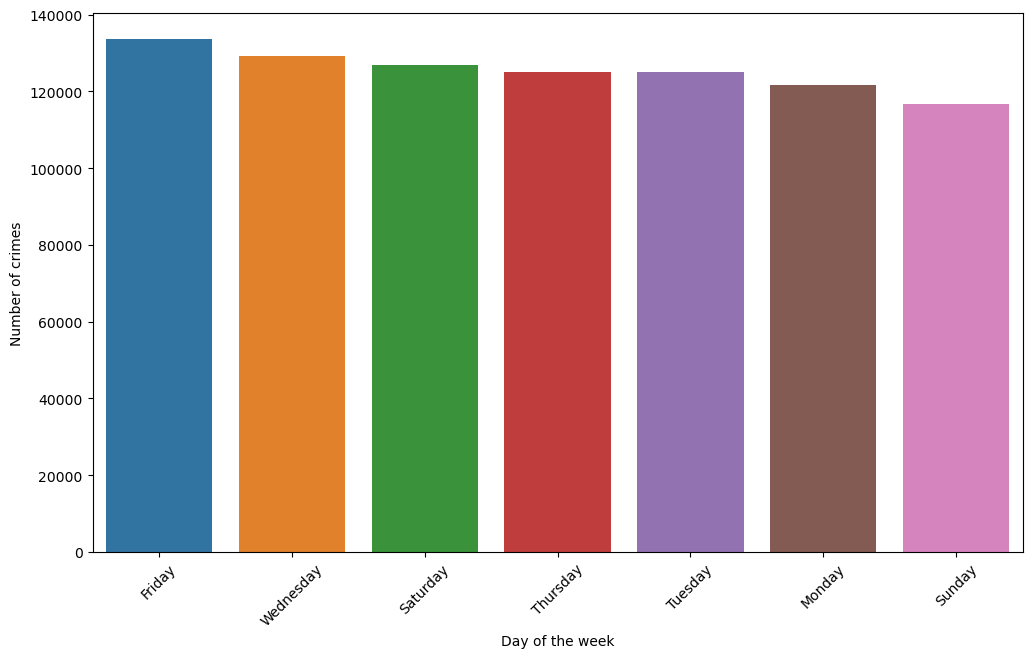

In [15]:
day_count = df["DayOfWeek"].value_counts()
print(day_count)

plt.figure(figsize = (12,7))
sns.barplot(x = day_count.index, y = day_count.values)
plt.xticks(rotation = 45)
plt.xlabel("Day of the week")
plt.ylabel("Number of crimes")
plt.show()

Converting DayOfWeek column into floats
- manually assigned a number to each day of the week
- mapped them to the DayOfWeek coulmn
- created a new column to store the float values
- the DayOfWeek is not needed anymore 

In [16]:
day_numbered = {
    "Monday" : 1,
    "Tuesday" : 2,
    "Wednesday" : 3,
    "Thursday" : 4,
    "Friday" : 5,
    "Saturday" : 6,
    "Sunday" : 7
}

df["day_num"] = df["DayOfWeek"].map(day_numbered)
df[["DayOfWeek", "day_num"]].head(-10)

,DayOfWeek,day_num
0,Wednesday,3
1,Wednesday,3
2,Wednesday,3
3,Wednesday,3
4,Wednesday,3
...,...,...
878034,Monday,1
878035,Monday,1
878036,Monday,1
878037,Monday,1


Converting Address column into binary numbered data
- all the addresses are either --
    1. intersections denoted by "/"
    2. blocks denoted by well..."blocks"
- so, same as before. map the values to the Address column 
- create two columns to store all the values

In [17]:
df["intersection"] = df["Address"].str.contains("/").astype(int)

df["block"] = df["Address"].str.contains("Block", case = False).astype(int)

df[["Address", "intersection", "block"]].head(-10)

,Address,intersection,block
0,OAK ST / LAGUNA ST,1,0
1,OAK ST / LAGUNA ST,1,0
2,VANNESS AV / GREENWICH ST,1,0
3,1500 Block of LOMBARD ST,0,1
4,100 Block of BRODERICK ST,0,1
...,...,...,...
878034,1000 Block of 22ND AV,0,1
878035,1300 Block of WEBSTER ST,0,1
878036,1300 Block of WEBSTER ST,0,1
878037,1300 Block of WEBSTER ST,0,1


Dividing Dates column and extracting relevant info from it
- convert Dates columnn into date type
- extract info like year, hour, day, is_weekend, is_night
- store all these info in seperate columns as integers

In [18]:
df["Dates"] = pd.to_datetime(df["Dates"])

df["year"] = df["Dates"].dt.year
df["month"] = df["Dates"].dt.month
df["hour"] = df["Dates"].dt.hour

df["is_weekend"] = df["Dates"].dt.dayofweek.isin([5,6]).astype(int)

df["is_night"] = ((df["hour"] > 21) | (df["hour"] < 6)).astype(int)    #9pm - 6am

df[["Dates", "year", "month", "hour", "is_weekend", "is_night", "day_num"]].head(-10)

,Dates,year,month,hour,is_weekend,is_night,day_num
0,2015-05-13 23:53:00,2015,5,23,0,1,3
1,2015-05-13 23:53:00,2015,5,23,0,1,3
2,2015-05-13 23:33:00,2015,5,23,0,1,3
3,2015-05-13 23:30:00,2015,5,23,0,1,3
4,2015-05-13 23:30:00,2015,5,23,0,1,3
...,...,...,...,...,...,...,...
878034,2003-01-06 01:30:00,2003,1,1,0,1,1
878035,2003-01-06 00:55:00,2003,1,0,0,1,1
878036,2003-01-06 00:55:00,2003,1,0,0,1,1
878037,2003-01-06 00:55:00,2003,1,0,0,1,1


In [19]:
df[["PdDistrict", "X", "Y", "day_num", "intersection", "block", "year", "month", "hour", "is_weekend", "is_night", "Category"]].head()

,PdDistrict,X,Y,day_num,intersection,block,year,month,hour,is_weekend,is_night,Category
0,NORTHERN,-122.425892,37.774599,3,1,0,2015,5,23,0,1,WARRANTS
1,NORTHERN,-122.425892,37.774599,3,1,0,2015,5,23,0,1,OTHER OFFENSES
2,NORTHERN,-122.424363,37.800414,3,1,0,2015,5,23,0,1,OTHER OFFENSES
3,NORTHERN,-122.426995,37.800873,3,0,1,2015,5,23,0,1,LARCENY/THEFT
4,PARK,-122.438738,37.771541,3,0,1,2015,5,23,0,1,LARCENY/THEFT


In [20]:
df = pd.get_dummies(df, columns = ["PdDistrict"], prefix = "District")
df.head()

,Dates,Category,Descript,DayOfWeek,Resolution,Address,X,Y,day_num,intersection,...,District_BAYVIEW,District_CENTRAL,District_INGLESIDE,District_MISSION,District_NORTHERN,District_PARK,District_RICHMOND,District_SOUTHERN,District_TARAVAL,District_TENDERLOIN
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,3,1,...,0,0,0,0,1,0,0,0,0,0
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,3,1,...,0,0,0,0,1,0,0,0,0,0
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,3,1,...,0,0,0,0,1,0,0,0,0,0
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873,3,0,...,0,0,0,0,1,0,0,0,0,0
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NONE,100 Block of BRODERICK ST,-122.438738,37.771541,3,0,...,0,0,0,0,0,1,0,0,0,0


In [22]:
le = LabelEncoder()

df["category_num"] = le.fit_transform(df["Category"])
df.head()

,Dates,Category,Descript,DayOfWeek,Resolution,Address,X,Y,day_num,intersection,...,District_CENTRAL,District_INGLESIDE,District_MISSION,District_NORTHERN,District_PARK,District_RICHMOND,District_SOUTHERN,District_TARAVAL,District_TENDERLOIN,category_num
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,3,1,...,0,0,0,1,0,0,0,0,0,37
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,3,1,...,0,0,0,1,0,0,0,0,0,21
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,3,1,...,0,0,0,1,0,0,0,0,0,21
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873,3,0,...,0,0,0,1,0,0,0,0,0,16
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NONE,100 Block of BRODERICK ST,-122.438738,37.771541,3,0,...,0,0,0,0,1,0,0,0,0,16


In [24]:
# Create a dictionary to map the integer codes back to the original names
# The le.classes_ attribute holds the category names in the order they were encoded (0, 1, 2, ...)
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("--- Category to Integer Mapping (Partial) ---")
# Display the first few mappings to check the order:
# Example: 'ARSON' will likely be 0, 'ASSAULT' will be 1, etc.
for name, code in list(category_mapping.items())[:10]:
    print(f"'{name}': {code}")

--- Category to Integer Mapping (Partial) ---
'ARSON': 0
'ASSAULT': 1
'BAD CHECKS': 2
'BRIBERY': 3
'BURGLARY': 4
'DISORDERLY CONDUCT': 5
'DRIVING UNDER THE INFLUENCE': 6
'DRUG/NARCOTIC': 7
'DRUNKENNESS': 8
'EMBEZZLEMENT': 9


In [25]:
df = df.drop(columns = ["Dates", "Category", "Descript", "DayOfWeek", "Resolution", "Address"])
df.head()

,X,Y,day_num,intersection,block,year,month,hour,is_weekend,is_night,...,District_CENTRAL,District_INGLESIDE,District_MISSION,District_NORTHERN,District_PARK,District_RICHMOND,District_SOUTHERN,District_TARAVAL,District_TENDERLOIN,category_num
0,-122.425892,37.774599,3,1,0,2015,5,23,0,1,...,0,0,0,1,0,0,0,0,0,37
1,-122.425892,37.774599,3,1,0,2015,5,23,0,1,...,0,0,0,1,0,0,0,0,0,21
2,-122.424363,37.800414,3,1,0,2015,5,23,0,1,...,0,0,0,1,0,0,0,0,0,21
3,-122.426995,37.800873,3,0,1,2015,5,23,0,1,...,0,0,0,1,0,0,0,0,0,16
4,-122.438738,37.771541,3,0,1,2015,5,23,0,1,...,0,0,0,0,1,0,0,0,0,16


In [26]:
df.isnull().sum()

X                      0
Y                      0
day_num                0
intersection           0
block                  0
year                   0
month                  0
hour                   0
is_weekend             0
is_night               0
District_BAYVIEW       0
District_CENTRAL       0
District_INGLESIDE     0
District_MISSION       0
District_NORTHERN      0
District_PARK          0
District_RICHMOND      0
District_SOUTHERN      0
District_TARAVAL       0
District_TENDERLOIN    0
category_num           0
dtype: int64

Model Calling

In [27]:
X = df.drop(columns = ["category_num"])
y = df["category_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth = 15, n_jobs = -1)

print("---Training model---")
model.fit(X_train, y_train)
print("---Training finished---")

---Training model---
---Training finished---


In [28]:
y_pred_probability = model.predict_proba(X_test)
y_pred = model.predict(X_test)

In [29]:
logloss = log_loss(y_test, y_pred_probability)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nMulticlass Log Loss on Validation Data: {logloss:.4f}")
print(f"\nMulticlass Accuracy score on Validation Data: {accuracy:.4f}")


Multiclass Log Loss on Validation Data: 2.3592

Multiclass Accuracy score on Validation Data: 0.2915


C:\Users\psaig\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
